### General Imports:


In [1]:
import os
import gymnasium as gym
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
from netsim.gym_basic.envs import MASKING_RMSA_ENV
from netsim.netSimPy import *
import numpy as np
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

logging.getLogger("tensorflow").setLevel(logging.FATAL)

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# FILES AND DIRECTORIES:
__file__ = "LGR_RMSA.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
log_dir = f"./tmp/{file_name}/"
# SIMULATION PARAMS:
EPISODE_LENGTH = 1000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 30000  # 300 Erlangs

networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/nsfnet"
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)
# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
)

env: MASKING_RMSA_ENV = Monitor(gym.make("MASKING_RMSA_ENV-v0", **env_args), log_dir)
eval_env: MASKING_RMSA_ENV = Monitor(
    gym.make("MASKING_RMSA_ENV-v0", **env_args), log_dir + "eval_env"
)

best_model_dir = f"./tmp/ACTION_RMSA_ENV/best_smooth_model"
expert = MaskablePPO.load(best_model_dir)

In [4]:
from sklearn.linear_model import LogisticRegression
from netsim.explainable.common.dagger import Dagger
from netsim.explainable.common.beta import linear_beta
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import make_pipeline


n_rounds = 8
beta_func = linear_beta(1, 0, n_rounds)

# model = make_pipeline(
#     RobustScaler(),
#     LogisticRegression(
#         class_weight="balanced", solver="lbfgs", multi_class="multinomial", max_iter=1000
#     ),
# )

student = LogisticRegression(
    class_weight="balanced", solver="lbfgs", multi_class="multinomial", max_iter=10000
)

dagger_trainer = Dagger(expert, student, env, beta_func)
student = dagger_trainer.train(n_rounds, timesteps_by_round=100000, n_evaluations=5000)
# Acceder al clasificador:
# student: LogisticRegression = model.named_steps["logisticregression"]

Starting round 1
Sampling new trajectories for round: {1} 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7624 [[ 654    3    1    0    0  149  137    0   14    5]
 [  39 1327   12    0    0    4  123    0    1   41]
 [   0    0    2    0    0    0    0    0    0    0]
 [   0    0    0   32    1    0    0    0    0    0]
 [   0    0    0    0   10    0    0    1    0    0]
 [  95    0    2    0    0  531   81    0    0    0]
 [ 156  117    8    0    0  196 1127    0    0    2]
 [   0    0    0    0    0    0    0   61    0    0]
 [   0    0    0    0    0    0    0    0   33    0]
 [   0    0    0    0    0    0    0    0    0   35]]
Starting round 2
Sampling new trajectories for round: 2 
Fitting student for round: 2 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7426 [[ 672    2    2    0    0  129  134    0   18   12]
 [  39 1324    2    0    0    1  110    0    0   74]
 [   0    0    5    0    0    0    0    0    0    0]
 [   0    0    0   26    0    0    0    1    0    0]
 [   0    0    0    0    5    0    0    0    0    0]
 [ 140    0    0    0    0  552   60    0    1    0]
 [ 221  153    8    0    0  176 1012    0    0    1]
 [   0    0    0    1    0    0    0   52    0    0]
 [   0    0    0    0    0    0    0    0   37    0]
 [   0    0    0    0    0    0    0    0    2   28]]
Starting round 3
Sampling new trajectories for round: 3 
Fitting student for round: 3 


...

0.69 [[ 558    2    6    0    0  237  151    0   12    5]
 [  84 1262    9    0    0    1   99    0    1  146]
 [   0    0    4    0    0    0    0    0    0    0]
 [   0    0    0   32    1    0    0    0    0    0]
 [   0    0    0    0   10    0    0    0    0    0]
 [ 122    0    1    0    0  523   53    0    1    0]
 [ 275  112   22    0    0  210  949    0    0    0]
 [   0    0    0    0    0    0    0   51    0    0]
 [   0    0    0    0    0    0    0    0   33    0]
 [   0    0    0    0    0    0    0    0    0   28]]
Starting round 7
Sampling new trajectories for round: 7 
Fitting student for round: 7 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6948 [[ 601    0    2    0    0  197  123    0   25   13]
 [  85 1255    4    0    0    0  105    0    0  132]
 [   0    0    2    0    0    0    0    0    0    0]
 [   0    0    0   24    0    0    0    0    0    0]
 [   0    0    0    0    9    0    0    0    0    0]
 [ 101    1    1    0    0  557   64    0    0    0]
 [ 301  136   17    0    0  216  915    0    1    1]
 [   0    0    0    0    0    0    0   51    0    0]
 [   1    0    0    0    0    0    0    0   31    0]
 [   0    0    0    0    0    0    0    0    0   29]]
Starting round 8
Sampling new trajectories for round: 8 
Fitting student for round: 8 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6892 [[ 584    5    3    0    0  193  128    0   28   12]
 [  80 1248    6    0    0    7   97    1    1  165]
 [   0    0    4    0    0    0    0    0    0    0]
 [   0    0    0   19    1    0    0    0    0    0]
 [   0    0    0    0    9    0    0    0    0    0]
 [ 117    1    3    0    0  554   28    0    0    0]
 [ 300  131   12    0    0  234  918    0    0    1]
 [   0    0    0    0    0    0    0   53    0    0]
 [   0    0    0    0    0    0    0    0   23    0]
 [   0    0    0    0    0    0    0    0    0   34]]


### Saving the agent


In [ ]:
import pickle as pkl

pickle_out = open("student_LGR.pkl", "wb")
pkl.dump(student, pickle_out)
pickle_out.close()
# pickle_out = open("student_LGR.pkl","rb")
# student = pkl.load(pickle_out)
# pickle_out.close()

### Global accuracy


In [6]:
from netsim.explainable.common.metrics import get_metrics
from netsim.explainable.common.rollout import generate_trajectories
from netsim.explainable.common.masking import predict_with_valid_classes, compute_mask

traj = generate_trajectories(200000, expert, env)
x_test = [t["obs"] for t in traj]
y_test = [int(t["action"]) for t in traj]

masking = compute_mask(env)
y_pred = predict_with_valid_classes(student, x_test, masking)
score = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=[i for i in range(15)])
print(f"Accuracy-score: {score}")
print(f'F1-score: {f1_score(y_test, y_pred, average="weighted")}')
print(conf_matrix)

Accuracy-score: 0.694235
F1-score: 0.7057296354634744
[[23996    51     0   193     0     0     2  7541     0  5074     0   773
    402     1     0]
 [ 3063 50220     0   332     0     0     0   204     0  4151     0    49
   5727     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    1     1     0   188     0     0     0     0     0     0     0     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    0     0     0     0     0   863    16     1     0     0     5     0
      0     0     0]
 [    0     0     0     0     0     0   335     0     0     0     0     0
      0     0     0]
 [ 4411    25     0    89     0     0     0 21555     0  2114     0    28
     15     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [12566  5520     0   526     0     1     0  8138     0 37394     0     9
     48     2    

In [7]:
get_metrics(conf_matrix)

Clase 1:
  Precision: 0.5447
  F1-score: 0.5846
  Sensibilidad (Recall): 0.6309
  Especificidad: 1.7095

Clase 2:
  Precision: 0.8996
  F1-score: 0.8400
  Sensibilidad (Recall): 0.7878
  Especificidad: 3.7128

Clase 3:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 4:
  Precision: 0.1416
  F1-score: 0.2477
  Sensibilidad (Recall): 0.9895
  Especificidad: 94.0000

Clase 5:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 6:
  Precision: 0.9920
  F1-score: 0.9835
  Sensibilidad (Recall): 0.9751
  Especificidad: 39.2273

Clase 7:
  Precision: 0.9306
  F1-score: 0.9640
  Sensibilidad (Recall): 1.0000
  Especificidad: inf

Clase 8:
  Precision: 0.5757
  F1-score: 0.6564
  Sensibilidad (Recall): 0.7634
  Especificidad: 3.2258

Clase 9:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 10:
  Precision: 0.7673
  F1-score: 0.6622
  Sensibilidad (Recall): 0.5824
  Especific

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:6: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(matrix) / np.sum(matrix, axis=0)
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:7: RuntimeWarning: invalid value encountered in divide
  recall = np.diag(matrix) / np.sum(matrix, axis=1)
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:8: RuntimeWarning: divide by zero encountered in divide
  specificity = np.diag(matrix) / (np.sum(matrix, axis=1) - np.diag(matrix))
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:8: RuntimeWarning: invalid value encountered in divide
  specificity = np.diag(matrix) / (np.sum(matrix, axis=1) - np.diag(matrix))


### Inter-path accuracy


In [8]:
n_conf_matrix = np.zeros(shape=(3, 3))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n_conf_matrix[ir // 5, ic // 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n_conf_matrix)
print(s[0])
print(n_conf_matrix)

0.763935
[[7.8045e+04 1.6972e+04 6.9520e+03]
 [2.3137e+04 7.0417e+04 1.0700e+02]
 [2.9000e+01 1.6000e+01 4.3250e+03]]


In [9]:
# Matriz de confusión proporcionada
n_conf_matrix = np.array(n_conf_matrix)

get_metrics(n_conf_matrix)

Clase 1:
  Precision: 0.7711
  F1-score: 0.7682
  Sensibilidad (Recall): 0.7654
  Especificidad: 3.2622

Clase 2:
  Precision: 0.8056
  F1-score: 0.7778
  Sensibilidad (Recall): 0.7518
  Especificidad: 3.0295

Clase 3:
  Precision: 0.3799
  F1-score: 0.5491
  Sensibilidad (Recall): 0.9897
  Especificidad: 96.1111



### Inter-spectrum accuracy


In [10]:
n2_conf_matrix = np.zeros(shape=(5, 5))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n2_conf_matrix[ir % 5, ic % 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n2_conf_matrix)
print(s[0])
print(n2_conf_matrix)

0.69461
[[2.6693e+04 8.5100e+02 7.9460e+03 1.9400e+02 5.0740e+03]
 [3.0630e+03 5.1745e+04 5.9500e+03 3.3200e+02 4.1510e+03]
 [4.4300e+03 7.0000e+01 2.2902e+04 9.0000e+01 2.1150e+03]
 [1.0000e+00 1.0000e+00 0.0000e+00 1.8800e+02 0.0000e+00]
 [1.2567e+04 5.5290e+03 8.1860e+03 5.2800e+02 3.7394e+04]]


In [11]:
# Matriz de confusión proporcionada
get_metrics(np.array(n2_conf_matrix))

Clase 1:
  Precision: 0.5709
  F1-score: 0.6100
  Sensibilidad (Recall): 0.6549
  Especificidad: 1.8978

Clase 2:
  Precision: 0.8892
  F1-score: 0.8384
  Sensibilidad (Recall): 0.7931
  Especificidad: 3.8341

Clase 3:
  Precision: 0.5091
  F1-score: 0.6141
  Sensibilidad (Recall): 0.7735
  Especificidad: 3.4157

Clase 4:
  Precision: 0.1411
  F1-score: 0.2470
  Sensibilidad (Recall): 0.9895
  Especificidad: 94.0000

Clase 5:
  Precision: 0.7673
  F1-score: 0.6622
  Sensibilidad (Recall): 0.5824
  Especificidad: 1.3948



In [12]:
def evaluate_bp_student(student, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.reset(options={"lambda": mLambda})
    observation = env.reset()[0]
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        # act = predict([observation], student, env)[0]
        act = predict_with_valid_classes(student, [observation], masking)[0]
        # act = student.predict([observation])[0]
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps


def evaluate_expert(expert, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.reset(options={"lambda": mLambda})
    observation = env.reset()
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        act, state = expert.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps

In [15]:
loads = [10000, 12500, 15000, 17500, 20000, 22500, 25000]
N_EVALUATIONS = 200000
lr_bp = []

for l in loads:
    bp = round(evaluate_bp_student(student, N_EVALUATIONS, l), 7)
    print(bp)
    lr_bp.append(bp)
print(lr_bp)

0.000125
0.000115
0.000245
0.000595
0.001725
0.003935
0.00814
[0.000125, 0.000115, 0.000245, 0.000595, 0.001725, 0.003935, 0.00814]


### features importance


[-1.00123707e-04 -7.62280361e-05 -1.04109343e-04 -1.08659014e-04
 -1.29838090e-04 -6.91866796e-05 -7.25909068e-06 -7.62234578e-06
 -1.99973705e-03 -7.44548339e-06  4.17939945e-02 -2.44381429e-02
  3.29919431e-03  1.66641948e-02  4.16568763e-02 -1.35639463e-02
 -3.68585884e-02 -1.13596757e-01 -5.99540711e-02  3.29507129e-02
  1.25683646e-01  1.83243014e-01 -6.26134047e-05 -1.24587434e-01
 -4.65499329e-05 -6.68286526e-05 -4.75579483e-05 -4.08704506e-05
 -1.78877048e-01 -1.93412933e-01 -8.58547765e-02 -4.70392221e-02
 -6.90932466e-02 -4.05897781e-02 -5.95111377e-02 -3.91085859e-02
 -6.28568154e-02 -3.95370008e-02 -5.77955317e-02  4.46801305e-03
 -2.03199755e-01  5.86392920e-03  4.53392392e-01  2.62431210e-02
  3.00521886e-01 -7.46219346e-02 -3.88470140e-02 -5.28318592e-02
 -3.70969029e-02 -5.56005762e-02 -3.74302225e-02 -1.09792513e-01
 -8.70538023e-04 -5.31040261e-01 -1.80463725e-03  3.16985176e-02
 -9.95492278e-02 -4.73379504e-02 -5.92367643e-02 -3.80688419e-02
 -5.89618838e-02 -3.77638

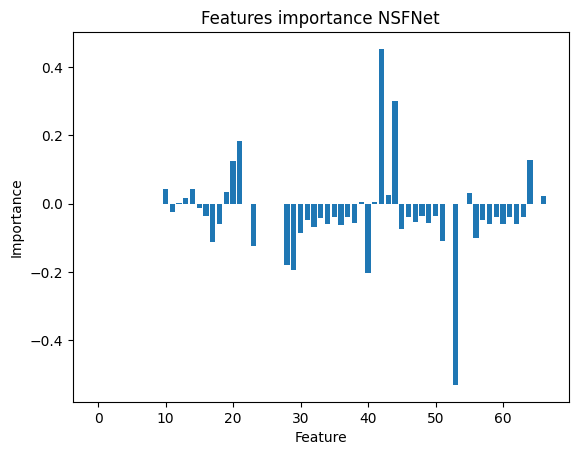

In [20]:
import pandas as pd

base_output_dir_features = f"./plots/{__file__}/features_importance_heuristic/"

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

for i, importances_sk in enumerate(student.coef_):
    # importances_sk = student.coef_[i]
    importance = pd.DataFrame(importances_sk)
    importance.to_csv(f"{output_dir}features_importance_{i}.csv")

importances_sk = student.coef_[4]
importance = pd.DataFrame(importances_sk)
importance.to_csv(f"{output_dir}features_importance_heuristic.csv")
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + "NSFNet.png")
plt.show()
#
#

[-7.54823505e-07 -1.16282867e-06 -1.04700023e-06 -1.40734054e-06
 -1.62323485e-06 -2.32201929e-06 -1.16330469e-06 -1.00105302e-06
 -1.81550750e-06 -5.43802027e-07 -7.96264728e-07 -1.30219400e-06
 -2.20461020e-06  1.82704075e-05 -1.50415380e-06 -1.59464266e-06
 -1.90340381e-06  8.91583419e-06 -1.35720247e-06 -1.86164098e-06
  8.37061402e-06 -1.31755506e-06 -1.19539633e-06 -1.51215580e-06
 -7.70586217e-07 -1.40653488e-06 -1.01235207e-06 -7.24399838e-07
 -5.98004625e-04 -2.81241302e-04 -4.84497152e-04 -1.54551265e-04
 -5.80532448e-04 -1.66227376e-04 -6.86888067e-04 -1.52638898e-04
 -7.96174364e-04 -1.73377387e-04  2.01636152e-04 -1.76999414e-05
 -5.32309718e-04  1.83804899e-03  2.15253513e-04  5.27206393e-03
  1.68908842e-04 -7.27359548e-04 -1.30784800e-04 -7.62192130e-04
 -1.19534471e-04 -8.60411707e-04 -1.16341931e-04  1.93379494e-04
 -7.10457221e-04 -2.77902523e-06 -6.49287114e-04 -1.64497960e-04
 -7.64696579e-04 -1.64476183e-04 -8.41084505e-04 -1.35481883e-04
 -8.91369298e-04 -1.21362

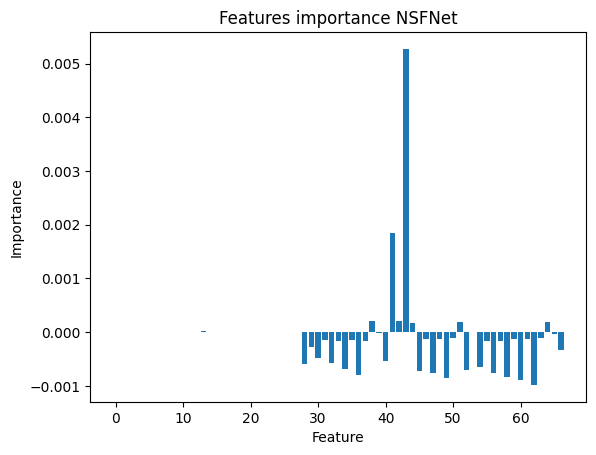

In [2]:
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import os

student_file = "student_LGR.pkl"
out_csv_file = "LGR_results/"
output_dir = out_csv_file

pickle_out = open(student_file, "rb")
student = pkl.load(pickle_out)
pickle_out.close()


os.makedirs(output_dir, exist_ok=True)

for i, importances_sk in enumerate(student.coef_):
    # importances_sk = student.coef_[i]
    importance = pd.DataFrame(importances_sk)
    importance.to_csv(f"{output_dir}features_importance_{i}.csv")


importances_sk = student.coef_[4]
importance = pd.DataFrame(importances_sk)
importance.to_csv(f"{output_dir}features_importance_heuristic.csv")
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + "NSFNet.png")
plt.show()